### importing necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import inspect
import shap
from mapie.regression import SplitConformalRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

### loaing installed python packages

In [2]:
from src.utils.config import INTERIM,PROCESSED,ROOT_DIR,CLEAN_DATA_FILE,ARTIFACTS,TRIAL_LOGS,FIGURES,MODELS
from sklearn.inspection import permutation_importance
from scripts.models import train_models
from src.features import feature_importance

Lahore Real Estate Price Prediction Pipeline


### Loading dataset files

In [3]:
os.chdir(ROOT_DIR/PROCESSED)
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")
y_train = pd.read_csv("y_train.csv")

### Modeling Using Random Forest, LightGBM (LGBM)

#### Random Forest

In [4]:
inspect.signature(train_models.random_forest)

<Signature (X_train, y_train, X_test, y_test)>

In [5]:
rf_mae,rf_rmse,rf_r2,rf_mape,rf_model_train_time,rf_model_inference_time,cv_results,rf_model_pred,rf_best_model = train_models.random_forest(X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [6]:
rf_mae

502182.1234428472

#### Log every trial

In [7]:
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,14.269473,1.090763,0.398639,0.340938,100,5,4,None,None,"{'n_estimators': 100, 'min_samples_split': 5, ...",-6.481475e+06,-3.608790e+06,-6.889731e+06,-4.628532e+06,-2.995733e+06,-4.920852e+06,1.537860e+06,9
1,55.665108,3.176228,0.758274,0.161623,500,2,1,None,10,"{'n_estimators': 500, 'min_samples_split': 2, ...",-7.029010e+06,-2.559891e+06,-4.973816e+06,-2.995518e+06,-2.255043e+06,-3.962656e+06,1.802444e+06,2
2,15.921856,1.852098,0.194100,0.041783,100,2,1,None,20,"{'n_estimators': 100, 'min_samples_split': 2, ...",-6.863381e+06,-2.695879e+06,-5.166950e+06,-2.771005e+06,-2.329284e+06,-3.965300e+06,1.763925e+06,3
3,9.598752,1.036163,0.651759,0.310342,300,5,4,sqrt,10,"{'n_estimators': 300, 'min_samples_split': 5, ...",-1.457300e+07,-1.182190e+07,-1.307437e+07,-1.285510e+07,-1.207350e+07,-1.287957e+07,9.669214e+05,29
4,5.839667,2.174889,0.321472,0.178212,100,10,4,log2,None,"{'n_estimators': 100, 'min_samples_split': 10,...",-1.404165e+07,-1.148966e+07,-1.256617e+07,-1.201561e+07,-1.126925e+07,-1.227647e+07,9.900916e+05,27
5,24.175687,1.008539,1.694145,0.726287,500,10,2,log2,30,"{'n_estimators': 500, 'min_samples_split': 10,...",-1.264136e+07,-9.804382e+06,-1.118641e+07,-1.119861e+07,-1.026996e+07,-1.102015e+07,9.724900e+05,18
6,38.185669,3.446800,0.423211,0.129895,300,5,2,None,None,"{'n_estimators': 300, 'min_samples_split': 5, ...",-6.317687e+06,-2.759986e+06,-5.578030e+06,-3.520412e+06,-2.493659e+06,-4.133955e+06,1.536804e+06,5
7,13.465471,1.844697,0.606281,0.129696,300,10,1,log2,20,"{'n_estimators': 300, 'min_samples_split': 10,...",-1.229244e+07,-9.242892e+06,-1.042667e+07,-1.052152e+07,-9.801790e+06,-1.045706e+07,1.027353e+06,13
8,46.272314,2.405281,0.772145,0.156396,500,2,2,None,20,"{'n_estimators': 500, 'min_samples_split': 2, ...",-6.372922e+06,-2.759332e+06,-5.552739e+06,-3.497315e+06,-2.485438e+06,-4.133549e+06,1.551672e+06,4
9,3.646954,0.466337,0.165965,0.047356,100,5,1,log2,20,"{'n_estimators': 100, 'min_samples_split': 5, ...",-1.161300e+07,-8.226692e+06,-1.038980e+07,-9.611735e+06,-9.232774e+06,-9.814800e+06,1.137208e+06,11


In [8]:
rf_r2

0.9987421354361166

In [9]:
mean_price = y_train.squeeze().mean()

trial_log_rf = cv_results.copy()

trial_log_rf["Trial"] = np.arange(1, len(trial_log_rf) + 1)

trial_log_rf["RMSE_PKR"] = (-cv_results["mean_test_score"]).to_numpy()

trial_log_rf["RMSE_%"] = (
    trial_log_rf["RMSE_PKR"].to_numpy() / mean_price
) * 100
trial_log_rf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,params,...,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,Trial,RMSE_PKR,RMSE_%
0,14.269473,1.090763,0.398639,0.340938,100,5,4,None,None,"{'n_estimators': 100, 'min_samples_split': 5, ...",...,-3.608790e+06,-6.889731e+06,-4.628532e+06,-2.995733e+06,-4.920852e+06,1.537860e+06,9,1,4.920852e+06,8.927155
1,55.665108,3.176228,0.758274,0.161623,500,2,1,None,10,"{'n_estimators': 500, 'min_samples_split': 2, ...",...,-2.559891e+06,-4.973816e+06,-2.995518e+06,-2.255043e+06,-3.962656e+06,1.802444e+06,2,2,3.962656e+06,7.188844
2,15.921856,1.852098,0.194100,0.041783,100,2,1,None,20,"{'n_estimators': 100, 'min_samples_split': 2, ...",...,-2.695879e+06,-5.166950e+06,-2.771005e+06,-2.329284e+06,-3.965300e+06,1.763925e+06,3,3,3.965300e+06,7.193641
3,9.598752,1.036163,0.651759,0.310342,300,5,4,sqrt,10,"{'n_estimators': 300, 'min_samples_split': 5, ...",...,-1.182190e+07,-1.307437e+07,-1.285510e+07,-1.207350e+07,-1.287957e+07,9.669214e+05,29,4,1.287957e+07,23.365453
4,5.839667,2.174889,0.321472,0.178212,100,10,4,log2,None,"{'n_estimators': 100, 'min_samples_split': 10,...",...,-1.148966e+07,-1.256617e+07,-1.201561e+07,-1.126925e+07,-1.227647e+07,9.900916e+05,27,5,1.227647e+07,22.271333
5,24.175687,1.008539,1.694145,0.726287,500,10,2,log2,30,"{'n_estimators': 500, 'min_samples_split': 10,...",...,-9.804382e+06,-1.118641e+07,-1.119861e+07,-1.026996e+07,-1.102015e+07,9.724900e+05,18,6,1.102015e+07,19.992176
6,38.185669,3.446800,0.423211,0.129895,300,5,2,None,None,"{'n_estimators': 300, 'min_samples_split': 5, ...",...,-2.759986e+06,-5.578030e+06,-3.520412e+06,-2.493659e+06,-4.133955e+06,1.536804e+06,5,7,4.133955e+06,7.499607
7,13.465471,1.844697,0.606281,0.129696,300,10,1,log2,20,"{'n_estimators': 300, 'min_samples_split': 10,...",...,-9.242892e+06,-1.042667e+07,-1.052152e+07,-9.801790e+06,-1.045706e+07,1.027353e+06,13,8,1.045706e+07,18.970658
8,46.272314,2.405281,0.772145,0.156396,500,2,2,None,20,"{'n_estimators': 500, 'min_samples_split': 2, ...",...,-2.759332e+06,-5.552739e+06,-3.497315e+06,-2.485438e+06,-4.133549e+06,1.551672e+06,4,9,4.133549e+06,7.498871
9,3.646954,0.466337,0.165965,0.047356,100,5,1,log2,20,"{'n_estimators': 100, 'min_samples_split': 5, ...",...,-8.226692e+06,-1.038980e+07,-9.611735e+06,-9.232774e+06,-9.814800e+06,1.137208e+06,11,10,9.814800e+06,17.805502


#### Savveing Log every trial

In [10]:
os.chdir(ROOT_DIR/TRIAL_LOGS)
trial_log_rf.to_csv("trial_log_rf.csv",index = False)

#### LightGBM (LGBM)

In [11]:
xgbm_mae,xgbm_rmse,xgbm_r2,xgbm_mape,xgbm_model_train_time,xgbm_model_inference_time,cv_results,xgbm_model_pred,xgbm_best_model = train_models.lgbm_model(X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 14183, number of used features: 19
[LightGBM] [Info] Start training from score 55122288.937460


In [12]:
xgbm_mae

436625.45945512684

In [13]:
xgbm_r2

0.9984123367036984

#### Log every trial

In [14]:
mean_price = y_train.squeeze().mean()

trial_log_xgbm = cv_results.copy()

trial_log_xgbm["Trial"] = np.arange(1, len(trial_log_xgbm) + 1)

trial_log_xgbm["RMSE_PKR"] = (-cv_results["mean_test_score"]).to_numpy()

trial_log_xgbm["RMSE_%"] = (
    trial_log_xgbm["RMSE_PKR"].to_numpy() / mean_price
) * 100
trial_log_xgbm

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_num_leaves,param_n_estimators,param_min_child_samples,param_max_depth,param_learning_rate,...,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,Trial,RMSE_PKR,RMSE_%
0,17.627148,0.404061,0.052192,0.005655,1.0,80,500,30,5,0.03,...,-5.022446e+06,-6.853078e+06,-6.719457e+06,-3.376991e+06,-5.854050e+06,1.460149e+06,19,1,5.854050e+06,10.620115
1,10.026450,5.827264,0.021851,0.000823,1.0,31,200,20,5,0.03,...,-4.147507e+06,-6.134930e+06,-4.936920e+06,-3.024155e+06,-5.038587e+06,1.393955e+06,11,2,5.038587e+06,9.140743
2,18.791841,1.297081,0.169054,0.017782,0.7,80,500,10,-1,0.03,...,-3.818510e+06,-5.398890e+06,-3.826338e+06,-2.458186e+06,-4.047988e+06,9.930085e+05,1,3,4.047988e+06,7.343650
3,3.534508,0.282812,0.017655,0.002769,0.8,80,100,10,-1,0.03,...,-4.237957e+06,-7.083038e+06,-5.749697e+06,-3.652337e+06,-5.478073e+06,1.336805e+06,13,4,5.478073e+06,9.938036
4,5.992968,0.724672,0.050993,0.004515,0.8,50,300,10,10,0.05,...,-4.162748e+06,-5.527176e+06,-4.448387e+06,-3.549046e+06,-4.652054e+06,7.888403e+05,4,5,4.652054e+06,8.439515
5,2.589240,0.336919,0.021315,0.001317,1.0,80,200,20,5,0.03,...,-4.034083e+06,-6.898877e+06,-5.751133e+06,-3.483870e+06,-5.588921e+06,1.635676e+06,15,6,5.588921e+06,10.139131
6,22.633634,1.024114,0.067720,0.014090,0.8,120,200,30,15,0.03,...,-6.118707e+06,-7.169138e+06,-7.846874e+06,-3.202181e+06,-6.399947e+06,1.707919e+06,22,7,6.399947e+06,11.610451
7,8.553709,4.621954,0.059446,0.009351,0.8,31,300,20,15,0.05,...,-4.080874e+06,-5.768881e+06,-4.759922e+06,-3.227436e+06,-4.927511e+06,1.253070e+06,7,8,4.927511e+06,8.939236
8,65.533616,3.839917,0.061092,0.008318,0.8,120,300,10,15,0.01,...,-6.595166e+06,-8.804803e+06,-7.907384e+06,-6.988541e+06,-7.884670e+06,9.856510e+05,25,9,7.884670e+06,14.303959
9,3.357272,0.477942,0.016716,0.003223,0.7,80,100,10,5,0.03,...,-4.260325e+06,-7.148508e+06,-5.944615e+06,-3.790836e+06,-5.550560e+06,1.310673e+06,14,10,5.550560e+06,10.069538


#### Saving Log every trial

In [15]:
os.chdir(ROOT_DIR/TRIAL_LOGS)
trial_log_xgbm.to_csv("trial_log_xgbm.csv",index = False)

### Model Comparison Table

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "LGBMRegressor"
    ],

    "MAE (PKR)": [
        rf_mae,
        xgbm_mae
    ],

    "RMSE (PKR)": [
        rf_rmse,
        xgbm_rmse
    ],

    "MAPE (%)": [
        rf_mape,
        xgbm_mape
    ],

    "R²": [
        rf_r2,
        xgbm_r2
    ],

    "Train Time (sec)": [
        rf_model_train_time,
        xgbm_model_train_time
    ],

    "Inference Time (sec)": [
        rf_model_inference_time,
        xgbm_model_inference_time
    ],
    "Final?": [
        "Yes",
        "No"
    ]  
})

comparison

,Model,MAE (PKR),RMSE (PKR),MAPE (%),R²,Train Time (sec),Inference Time (sec),Final?
0,Random Forest,502182.123443,2.318305e+06,1.125778,0.998742,361.757587,0.052361,Yes
1,LGBMRegressor,436625.459455,2.604551e+06,0.764557,0.998412,281.278310,0.095430,No


- **we can see clearly Random Forse performe well then LGBMRegressor.we choose Random Forse for lohore price prediction.**

### Feature Importance

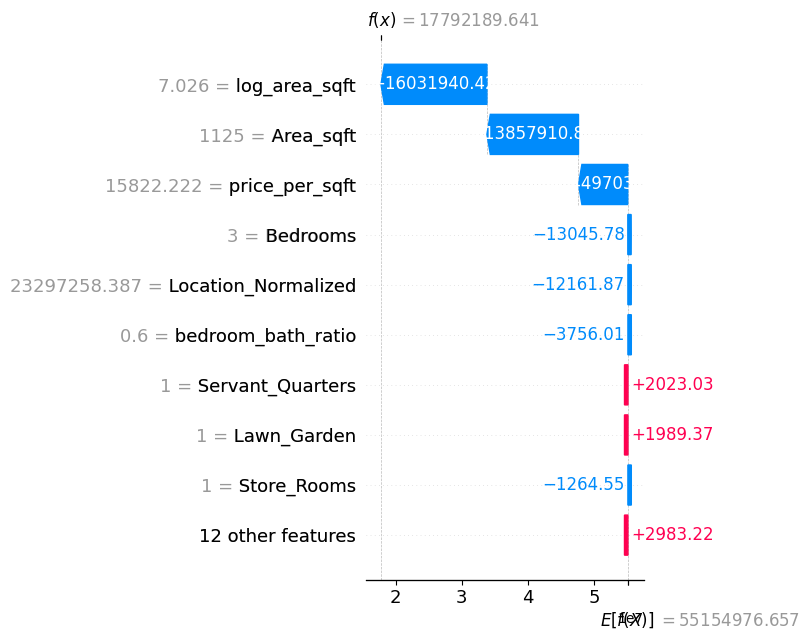

In [17]:
feature_importance.features_important_shap(rf_best_model,X_test)

In [18]:
Importance = feature_importance.features_important_permutation(rf_best_model,X_test,y_test)

In [19]:
low_features = Importance.loc[
    Importance["Importance"] < 0.001,
    "Feature"
]


In [20]:
Importance

,Feature,Importance
18,price_per_sqft,4.348148e-01
17,log_area_sqft,3.552715e-01
14,Area_sqft,2.518121e-01
1,Bathrooms,9.995747e-05
16,bedroom_bath_ratio,3.467752e-05
4,Servant_Quarters,3.366470e-05
0,Bedrooms,3.257750e-05
3,Store_Rooms,1.542343e-05
2,Kitchens,1.494397e-05
9,Dining_Room,1.486009e-05


In [21]:
low_features

1               Bathrooms
16     bedroom_bath_ratio
4        Servant_Quarters
0                Bedrooms
3             Store_Rooms
2                Kitchens
9             Dining_Room
8            Drawing_Room
7              Study_Room
11          Swimming_Pool
19             Type_House
20       Purpose_For Sale
10            Lawn_Garden
13    Lounge_Sitting_Room
12     Electricity_Backup
6                     Gym
5               Furnished
15    Location_Normalized
Name: Feature, dtype: object

### Residual Analysis

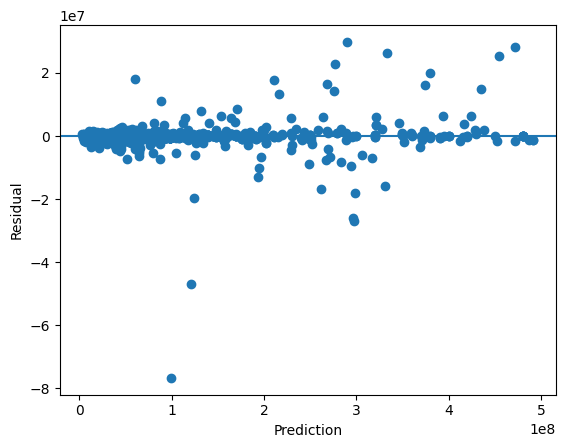

In [22]:
residual = y_test.squeeze() - rf_model_pred

plt.scatter(rf_model_pred, residual)

plt.axhline(0)

plt.xlabel("Prediction")

plt.ylabel("Residual")

plt.show()

### Conformal prediction via MAPIE (Model Agnostic Prediction Interval Estimator)

In [23]:
X_train_mapie, X_cal_mapie, y_train_mapie, y_cal_mapie = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [24]:
rf_best_model.fit(X_train_mapie,y_train_mapie)

C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [25]:
mapie = SplitConformalRegressor(
    estimator=rf_best_model,
    confidence_level=0.90
)
mapie.conformalize(X_cal_mapie, y_cal_mapie)

C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\KISHORE\anaconda3\envs\intern\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [26]:
pred, intervals = mapie.predict_interval(X_test)

In [27]:
pred

array([17806222.60797999, 24078452.16961919, 23950712.82680675, ...,
       22422848.71542722, 52472870.78055803, 11951664.889443  ],
      shape=(3546,))

In [28]:
intervals

array([[[17135266.04590045],
        [18477179.17005953]],

       [[23407495.60753965],
        [24749408.73169873]],

       [[23279756.26472722],
        [24621669.38888629]],

       ...,

       [[21751892.15334769],
        [23093805.27750676]],

       [[51801914.2184785 ],
        [53143827.34263757]],

       [[11280708.32736346],
        [12622621.45152253]]], shape=(3546, 2, 1))

In [29]:
lower = intervals[:, 0].ravel()
upper = intervals[:, 1].ravel()

In [30]:
pred = np.ravel(pred)
y_test = np.ravel(y_test)

In [31]:
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": pred,
    "Lower Bound": lower,
    "Upper Bound": upper
})

results.head()

,Actual,Prediction,Lower Bound,Upper Bound
0,17800000.0,1.780622e+07,1.713527e+07,1.847718e+07
1,24400000.0,2.407845e+07,2.340750e+07,2.474941e+07
2,25000000.0,2.395071e+07,2.327976e+07,2.462167e+07
3,37000000.0,3.636845e+07,3.569750e+07,3.703941e+07
4,18500000.0,1.829099e+07,1.762003e+07,1.896195e+07


In [32]:
inside = (y_test >= lower) & (y_test <= upper)

coverage = inside.mean()

print(f"Coverage: {coverage:.4f}")
print(f"Coverage (%): {coverage*100:.2f}%")

Coverage: 0.9010
Coverage (%): 90.10%


### Saving Models

In [33]:
os.chdir(ROOT_DIR/MODELS)
joblib.dump(rf_best_model, "rf_best_model.pkl")
joblib.dump(mapie, "mapie_rf.pkl")
print("models Saved Successfully!")

models Saved Successfully!
